1- Imports, Data Preparation and First Look

In [153]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.patches as mpatches

# Load the data
team_centric_matches = pd.read_csv("../data/processed/final_dataset.csv")
team_centric_matches['date'] = pd.to_datetime(team_centric_matches['date'])

# Only the league matches
league_matches = team_centric_matches[team_centric_matches['competition'] != 'Champions_League'].copy()

print(f"total league matches to be analyzed: {len(league_matches)}")

total league matches to be analyzed: 8570


### Question 1: Do Teams Perform Worse in Their Domestic Leagues After Champions League Matches?

To answer this question, the dataset will be divided into two main groups:

- **UCL-Affected Group:** League matches played within 6 days after a UCL match (`ucl_impact_category` = `severe` or `moderate`).

- **Control Group:** League matches with no expected UCL fatigue effect (`ucl_impact_category` = `no_effect`).

Total Matches (Severe Impact - ≤3 days rest): 735
Total Matches (Moderate Impact - 4 to 6 days rest): 342
Total Matches (Control Group - Rested): 3036

Mean Points (Severe): 1.920
Mean Points (Moderate): 1.830
Mean Points (Control): 1.877

Performance Difference (Severe vs Control): 2.27%
Performance Difference (Moderate vs Control): -2.49%

--- Statistical Significance ---
Severe vs Control -> P-Value: 0.4208 (Significant: False)
Moderate vs Control -> P-Value: 0.5174 (Significant: False)

CONCLUSION: Champions League matches statistically do NOT AFFECT league performance.


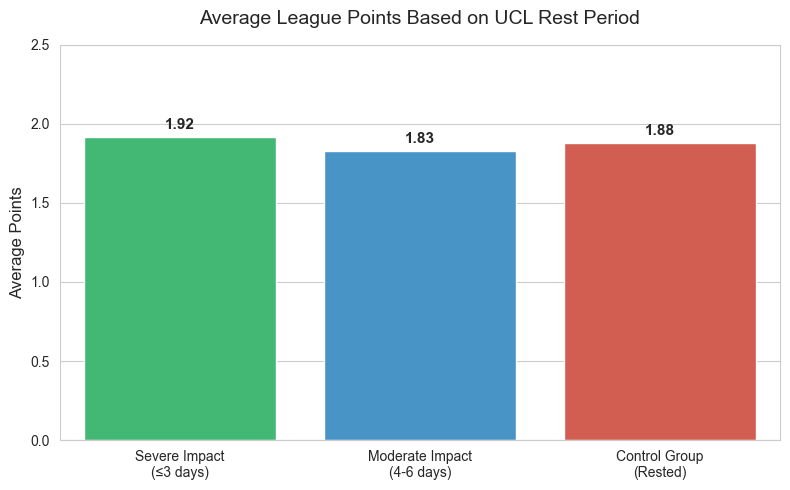

In [154]:
# 1. only consider the seasons in which teams played in the Champions League 
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()

# filter league matches only with active Champions League seasons 
valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')

# 2. divide the groups according to their fatigue levels.
severe_matches = valid_league_matches[valid_league_matches['ucl_impact_category'] == 'severe']
moderate_matches = valid_league_matches[valid_league_matches['ucl_impact_category'] == 'moderate']
control_matches = valid_league_matches[valid_league_matches['ucl_impact_category'] == 'no_effect']
print(f"Total Matches (Severe Impact - ≤3 days rest): {severe_matches.shape[0]}")
print(f"Total Matches (Moderate Impact - 4 to 6 days rest): {moderate_matches.shape[0]}")
print(f"Total Matches (Control Group - Rested): {control_matches.shape[0]}\n")

# Calculate the Avg. points
mean_severe = severe_matches['points'].mean()
mean_moderate = moderate_matches['points'].mean()
mean_control = control_matches['points'].mean()
print(f"Mean Points (Severe): {mean_severe:.3f}")
print(f"Mean Points (Moderate): {mean_moderate:.3f}")
print(f"Mean Points (Control): {mean_control:.3f}\n")
print(f"Performance Difference (Severe vs Control): {((mean_severe - mean_control) / mean_control) * 100:.2f}%")
print(f"Performance Difference (Moderate vs Control): {((mean_moderate - mean_control) / mean_control) * 100:.2f}%\n")

# 3. Statistical tests (T-Test)
t_stat_sev, p_value_sev = stats.ttest_ind(severe_matches['points'], control_matches['points'], equal_var=False)
t_stat_mod, p_value_mod = stats.ttest_ind(moderate_matches['points'], control_matches['points'], equal_var=False)
print("--- Statistical Significance ---")
print(f"Severe vs Control -> P-Value: {p_value_sev:.4f} (Significant: {p_value_sev < 0.05})")
print(f"Moderate vs Control -> P-Value: {p_value_mod:.4f} (Significant: {p_value_mod < 0.05})\n")
if p_value_sev < 0.05 or p_value_mod < 0.05:
    print("CONCLUSION: Champions League fatigue statistically AFFECTS league performance.")
else:
    print("CONCLUSION: Champions League matches statistically do NOT AFFECT league performance.")

# 4. Plotting
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
categories = ['Severe Impact\n(≤3 days)', 'Moderate Impact\n(4-6 days)', 'Control Group\n(Rested)']
means = [mean_severe, mean_moderate, mean_control]

ax = sns.barplot(
    x=categories, 
    y=means, 
    hue=categories, 
    palette=['#2ecc71', '#3498db', '#e74c3c'], 
    legend=False
)
plt.title("Average League Points Based on UCL Rest Period", fontsize=14, pad=15)
plt.ylabel("Average Points", fontsize=12)
plt.ylim(0, 2.5)

# Avg. points
for i, v in enumerate(means):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

Question 2: How does league performance vary based on recovery time after Champions League matches

Baseline Performance (Rested): 1.873 Points



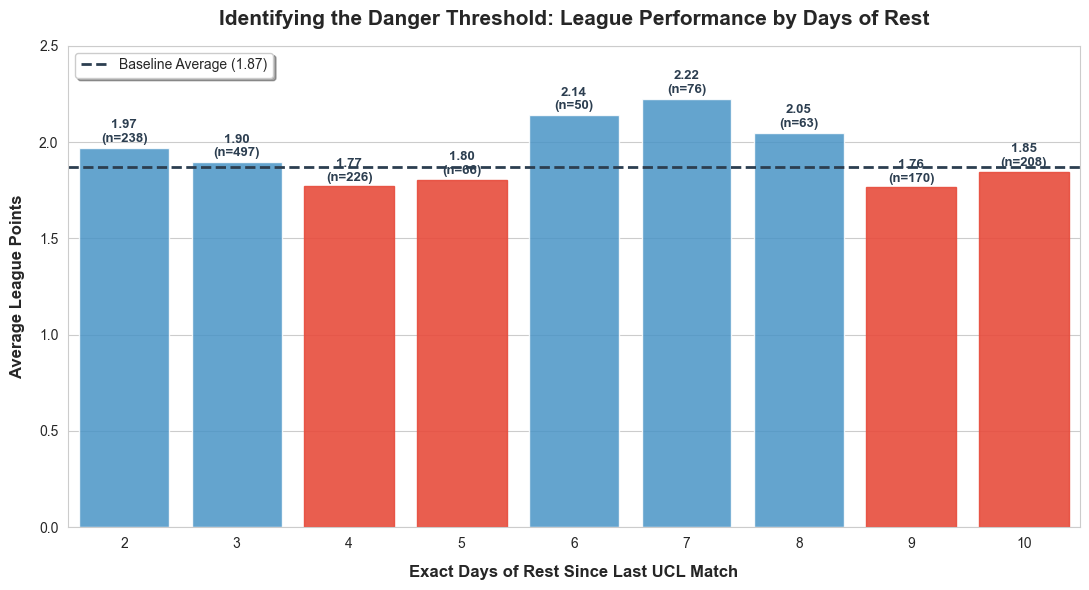

In [155]:
# 1. Filter the valid league matches for active UCL seasons
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()
valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')

# 2. Filter for matches that happen within 2 to 10 days of a UCL match
# (We start at 2 days because there are practically 0 matches played 1 day after)
threshold_data = valid_league_matches[
    (valid_league_matches['days_since_last_ucl_match'] >= 2) & 
    (valid_league_matches['days_since_last_ucl_match'] <= 10)
].copy()

# 3. Calculate daily performance (mean points and sample size)
daily_performance = threshold_data.groupby('days_since_last_ucl_match').agg(
    mean_points=('points', 'mean'),
    match_count=('points', 'count')
).reset_index()
# Convert days to integer for cleaner plotting
daily_performance['days_since_last_ucl_match'] = daily_performance['days_since_last_ucl_match'].astype(int)

# 4. Calculate Baseline (Control Group: >10 days rest or completely rested)
baseline_performance = valid_league_matches[
    (valid_league_matches['days_since_last_ucl_match'] > 10) | 
    (valid_league_matches['days_since_last_ucl_match'].isna())
]['points'].mean()
print(f"Baseline Performance (Rested): {baseline_performance:.3f} Points\n")

# 5. Visualization Setup
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")
ax = sns.barplot(
    data=daily_performance, 
    x='days_since_last_ucl_match', 
    y='mean_points',
    color='#3498db',
    alpha=0.85
)
plt.axhline(y=baseline_performance, color='#2c3e50', linestyle='--', linewidth=2, label=f'Baseline Average ({baseline_performance:.2f})')

# 6. Highlight the "Danger Zone" 
# Any day where the average points drop below the baseline will be painted RED
for p in ax.patches:
    if p.get_height() < baseline_performance:
        p.set_color('#e74c3c')
        p.set_alpha(0.9)

# 7. Add text labels on top of the bars showing the average points & (n = match count)
for i, row in daily_performance.iterrows():
    ax.text(
        i, row['mean_points'] + 0.03, 
        f"{row['mean_points']:.2f}\n(n={int(row['match_count'])})", 
        ha='center', fontsize=9.5, fontweight='bold', color='#2c3e50'
    )

# Formatting
plt.title("Identifying the Danger Threshold: League Performance by Days of Rest", fontsize=15, pad=15, fontweight='bold')
plt.xlabel("Exact Days of Rest Since Last UCL Match", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Average League Points", fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, 2.5)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Question 3: Is the decline (if any) after Champions League matches more pronounced in away games?


--- Numerical Breakdown (Average Points) ---
Rest Period  Control (Rested)  Severe (≤3 Days)  Moderate (4-6 Days)
Venue                                                               
Away Match           1.697165          1.715116             1.712500
Home Match           2.065364          2.099744             1.934066




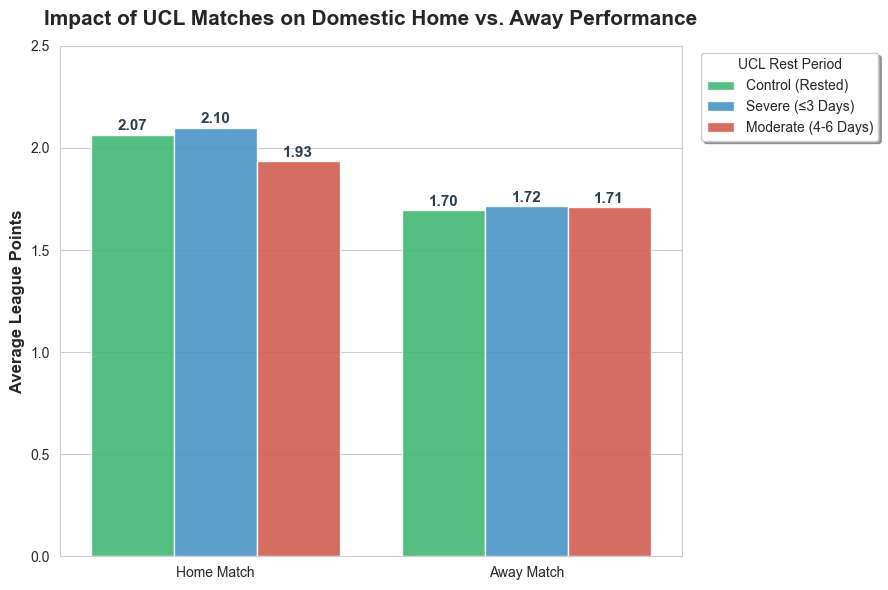

In [156]:
# 1. Filter the valid league matches for active UCL seasons
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()

valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')

# 2. Add a clear label for Home/Away
valid_league_matches['Venue'] = valid_league_matches['is_home'].map({True: 'Home Match', False: 'Away Match'})

# 3. Define the custom order and labels for categories
category_labels = ['Control (Rested)', 'Severe (≤3 Days)', 'Moderate (4-6 Days)']

# Map the raw categories to better, readable names for the plot
valid_league_matches['Rest Period'] = valid_league_matches['ucl_impact_category'].map({
    'no_effect': 'Control (Rested)',
    'severe': 'Severe (≤3 Days)',
    'moderate': 'Moderate (4-6 Days)'
})

# 4. Group data to calculate means for printing out the numerical stats
home_away_stats = valid_league_matches.groupby(['Venue', 'Rest Period']).agg(
    mean_points=('points', 'mean'),
    match_count=('points', 'count')
).reset_index()

# Print the numerical breakdown in the console
print("\n--- Numerical Breakdown (Average Points) ---")
print(home_away_stats.pivot(index='Venue', columns='Rest Period', values='mean_points').reindex(columns=category_labels))
print("\n")

# 5. Visualization Setup
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Create grouped barplot
ax = sns.barplot(
    data=valid_league_matches,
    x='Venue',
    y='points',
    hue='Rest Period',
    hue_order=category_labels,
    palette=['#2ecc71', '#3498db', '#e74c3c'],
    errorbar=None,
    alpha=0.9
)

# 6. Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + 0.02, 
            f'{height:.2f}', 
            ha='center', fontsize=11, fontweight='bold', color='#2c3e50'
        )

# 7. Formatting the chart
plt.title("Impact of UCL Matches on Domestic Home vs. Away Performance", fontsize=15, pad=15, fontweight='bold')
plt.xlabel("", fontsize=12)
plt.ylabel("Average League Points", fontsize=12, fontweight='bold')
plt.ylim(0, 2.5)
# Adjust legend to be outside the plot
plt.legend(title='UCL Rest Period', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()


Question 4: Does the goal scoring / conceding ability of teams change after playing in the Champions League?

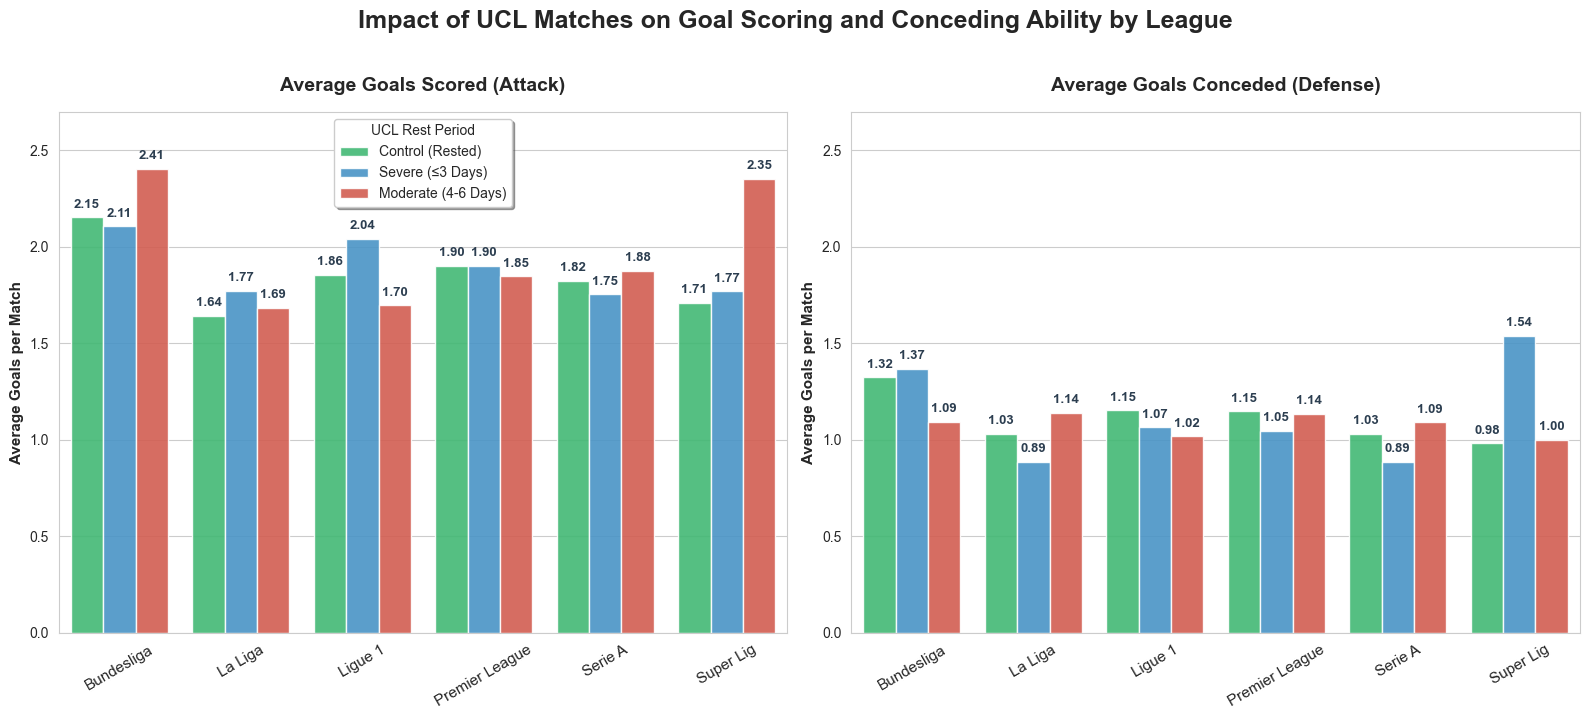

In [157]:
# 1. Filter the valid league matches for active UCL seasons
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()

valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')

# 2. Define the custom order and labels for categories
category_labels = ['Control (Rested)', 'Severe (≤3 Days)', 'Moderate (4-6 Days)']

# Map the raw categories to better, readable names for the plot
valid_league_matches['Rest Period'] = valid_league_matches['ucl_impact_category'].map({
    'no_effect': 'Control (Rested)',
    'severe': 'Severe (≤3 Days)',
    'moderate': 'Moderate (4-6 Days)'
})

# Rename the competitions to remove underscores for better presentation
valid_league_matches['competition'] = valid_league_matches['competition'].str.replace('_', ' ')

# 3. Aggregate data for Goals Scored and Goals Conceded
goal_stats = valid_league_matches.groupby(['competition', 'Rest Period']).agg(
    goals_scored=('target_team_goals', 'mean'),
    goals_conceded=('opponent_team_goals', 'mean')
).reset_index()

# Melt the dataframe so we can easily plot it side-by-side with seaborn
melted_stats = pd.melt(
    goal_stats, 
    id_vars=['competition', 'Rest Period'], 
    value_vars=['goals_scored', 'goals_conceded'],
    var_name='Metric', 
    value_name='Average Goals'
)

# Rename the metrics for the subplot titles
melted_stats['Metric'] = melted_stats['Metric'].map({
    'goals_scored': 'Average Goals Scored (Attack)',
    'goals_conceded': 'Average Goals Conceded (Defense)'
})

# 4. Visualization Setup: 1 Row, 2 Columns
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("whitegrid")
palette = ['#2ecc71', '#3498db', '#e74c3c']

metrics = ['Average Goals Scored (Attack)', 'Average Goals Conceded (Defense)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    subset = melted_stats[melted_stats['Metric'] == metric]
    
    sns.barplot(
        data=subset,
        x='competition',
        y='Average Goals',
        hue='Rest Period',
        hue_order=category_labels,
        palette=palette,
        ax=ax,
        alpha=0.9
    )
    
    # Subplot Formatting
    ax.set_title(metric, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Average Goals per Match", fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    ax.set_ylim(0, 2.7)
    
    # Add value labels slightly above the bars
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 0.05, 
                f'{height:.2f}', 
                ha='center', fontsize=9.5, color='#2c3e50', rotation=0, fontweight='bold'
            )
            
    # Clean up legends: only show legend on the first chart
    if i == 0:
        ax.legend(title='UCL Rest Period', frameon=True, shadow=True, fontsize=10)
    else:
        ax.get_legend().remove()

# Main Title
plt.suptitle("Impact of UCL Matches on Goal Scoring and Conceding Ability by League", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Question 5: Does playing in the Champions League season overall affect league performance?

C:\Users\Emre Cem\AppData\Local\Temp\ipykernel_26896\402789832.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  macro_comparison['is_ucl_season'] = macro_comparison['is_ucl_season'].fillna(False).infer_objects(copy=False)


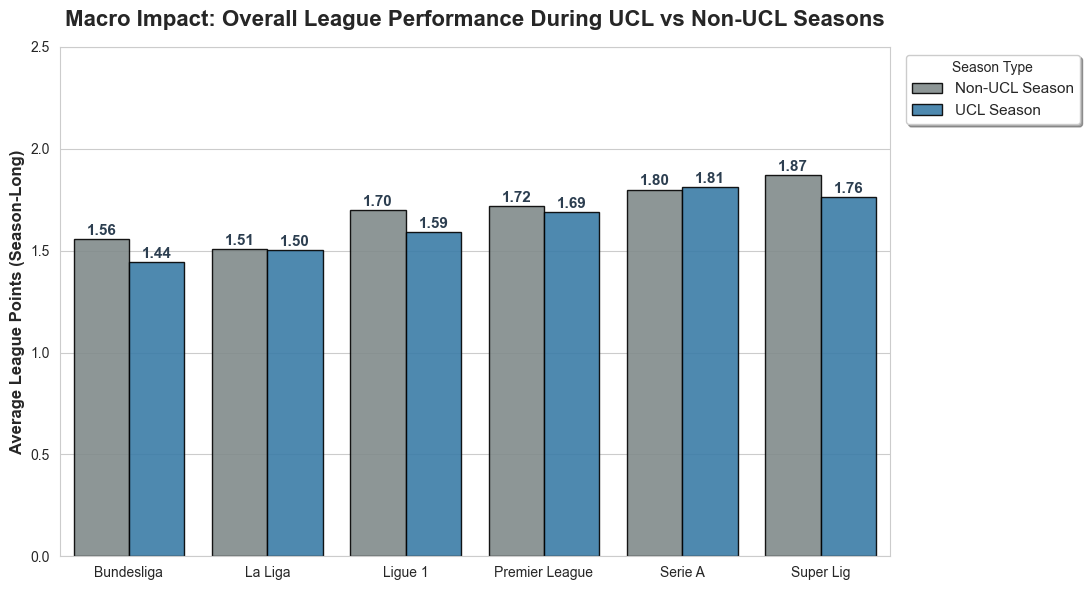

In [158]:
# 1. Identify UCL active seasons for each team
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()
active_ucl_seasons['is_ucl_season'] = True

# 2. Calculate seasonal average points for each team in the domestic league
league_matches = team_centric_matches[team_centric_matches['competition'] != 'Champions_League'].copy()
season_stats = league_matches.groupby(['target_team', 'season', 'competition'])['points'].mean().reset_index()

# 3. Merge the UCL flag
macro_comparison = pd.merge(season_stats, active_ucl_seasons, on=['target_team', 'season'], how='left')

# Fix future warning by using infer_objects
macro_comparison['is_ucl_season'] = macro_comparison['is_ucl_season'].fillna(False).infer_objects(copy=False)

# 4. EXCLUDE ALWAYS-UCL TEAMS (Like Bayern, Man City)
# Keep only teams that have BOTH UCL and Non-UCL seasons in the dataset
team_variety = macro_comparison.groupby('target_team')['is_ucl_season'].nunique()
valid_teams = team_variety[team_variety == 2].index

final_macro_df = macro_comparison[macro_comparison['target_team'].isin(valid_teams)].copy()
final_macro_df['competition'] = final_macro_df['competition'].str.replace('_', ' ')

# 5. Calculate Average Points per team for UCL vs Non-UCL
# We aggregate by team first so that the league average isn't skewed by one team having 5 non-UCL seasons and 1 UCL season
team_level_stats = final_macro_df.groupby(['competition', 'target_team', 'is_ucl_season'])['points'].mean().unstack()
team_level_stats = team_level_stats.dropna() # Extra safety
team_level_stats.columns = ['Non-UCL Season', 'UCL Season']
team_level_stats = team_level_stats.reset_index()

# 6. Now aggregate to League level
league_level_stats = team_level_stats.groupby('competition')[['Non-UCL Season', 'UCL Season']].mean().reset_index()

# Melt the dataframe for seaborn plotting
melted_macro = pd.melt(
    league_level_stats, 
    id_vars=['competition'], 
    value_vars=['Non-UCL Season', 'UCL Season'],
    var_name='Season Type', 
    value_name='Average Points'
)

# 7. Visualization Setup
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")

# Create grouped barplot
ax = sns.barplot(
    data=melted_macro,
    x='competition',
    y='Average Points',
    hue='Season Type',
    palette=['#7f8c8d', '#2980b9'], # Grey for Non-UCL, Bright Blue for UCL
    errorbar=None,
    alpha=0.9,
    edgecolor='black'
)

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + 0.02, 
            f'{height:.2f}', 
            ha='center', fontsize=11, fontweight='bold', color='#2c3e50'
        )

# Formatting
plt.title("Macro Impact: Overall League Performance During UCL vs Non-UCL Seasons", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("")
plt.ylabel("Average League Points (Season-Long)", fontsize=12, fontweight='bold')
plt.ylim(0, 2.5)

# Adjust legend
plt.legend(title='Season Type', frameon=True, shadow=True, fontsize=11, loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()


Question 6: Does deeper progression in the CL make the effect stronger?

C:\Users\Emre Cem\AppData\Local\Temp\ipykernel_26896\2026645033.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


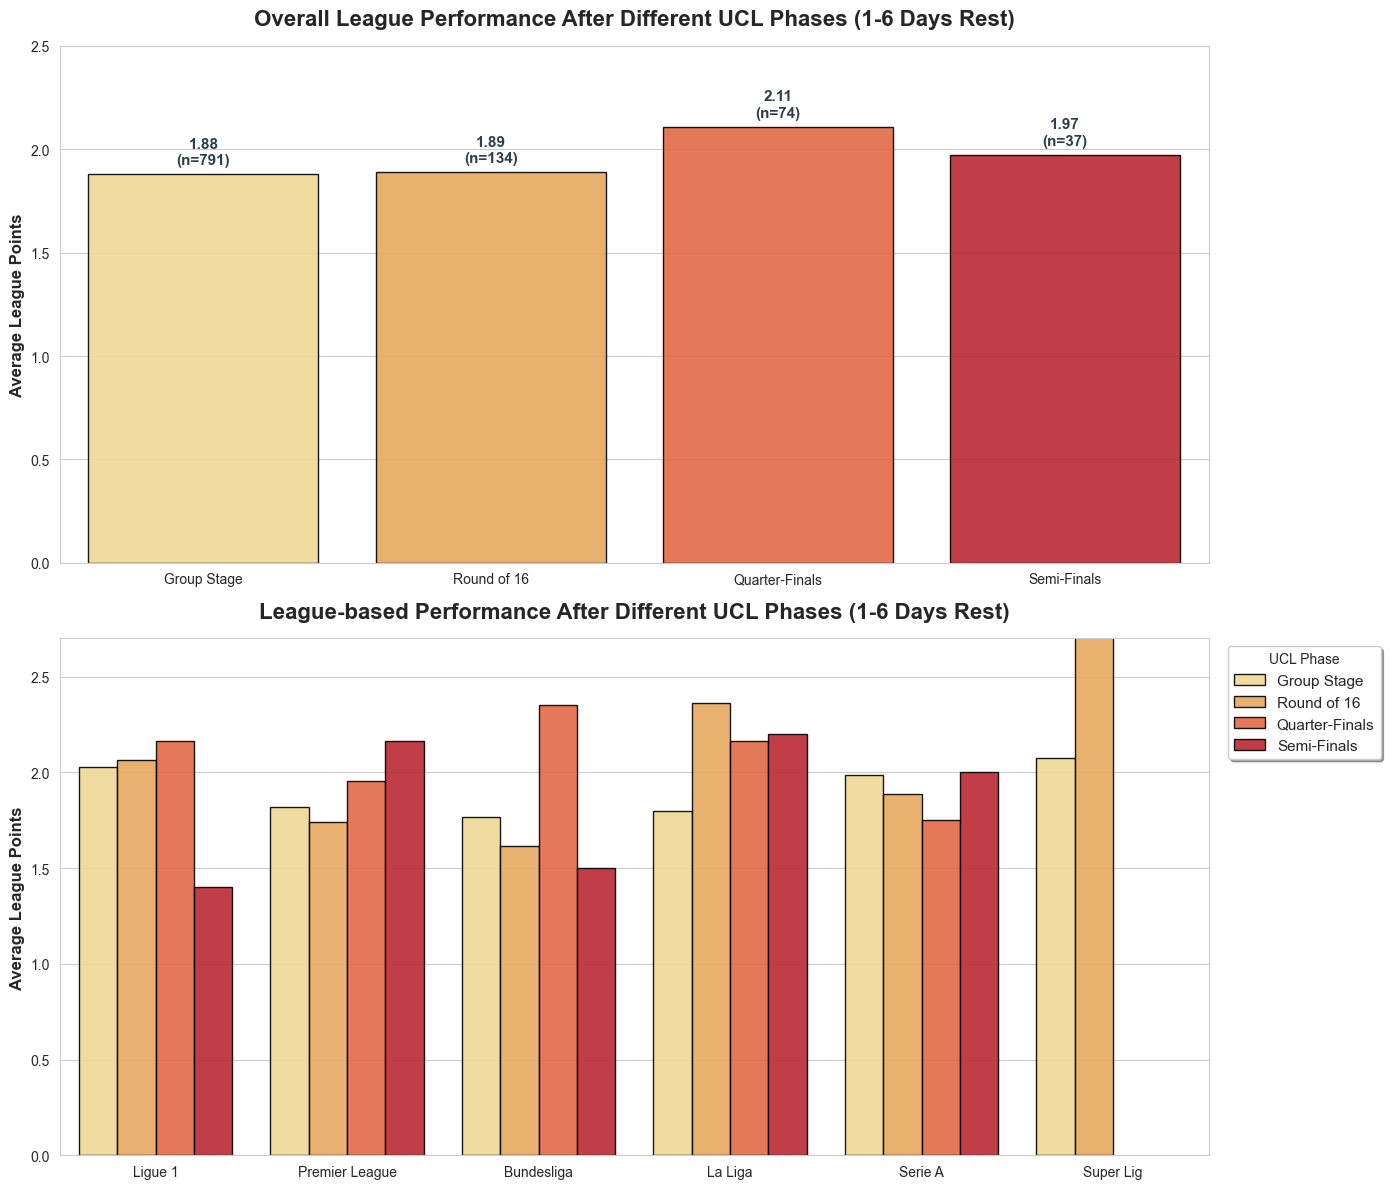

In [159]:
# 1. Get UCL Matches to serve as a lookup table for stages
ucl_only_matches = team_centric_matches[team_centric_matches['competition'] == 'Champions_League'].copy()
ucl_lookup = ucl_only_matches[['target_team', 'date', 'stage']].copy()
ucl_lookup.columns = ['target_team', 'last_ucl_date', 'last_ucl_stage']

# 2. Get valid league matches for active UCL seasons
active_ucl_seasons = ucl_only_matches[['target_team', 'season']].drop_duplicates()
valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')

# Sort both datasets chronologically for an accurate backward merge
valid_league_matches = valid_league_matches.sort_values('date')
ucl_lookup = ucl_lookup.sort_values('last_ucl_date')

# 3. Merge to find the EXACT stage of the preceding UCL match for every league match
league_with_ucl_stage = pd.merge_asof(
    valid_league_matches,
    ucl_lookup,
    left_on='date',
    right_on='last_ucl_date',
    by='target_team',
    direction='backward',
    allow_exact_matches=False
)

# 4. Filter for only matches that actually suffered from fatigue (Severe + Moderate -> ≤6 days rest)
affected_matches = league_with_ucl_stage[
    (league_with_ucl_stage['days_since_last_ucl_match'] > 0) & 
    (league_with_ucl_stage['days_since_last_ucl_match'] <= 6)
].copy()

# 5. Categorize the UCL stages correctly
def categorize_progression(stage_str):
    if pd.isna(stage_str):
        return 'Unknown'
    stage_str = str(stage_str).lower()
    
    if 'group' in stage_str or stage_str.isdigit():
        return 'Group Stage'
    elif 'r16' in stage_str or '16' in stage_str:
        return 'Round of 16'
    elif 'quarter' in stage_str or 'qf' in stage_str:
        return 'Quarter-Finals'
    elif 'semi' in stage_str or 'sf' in stage_str:
        return 'Semi-Finals'
    else:
        return 'Other'

affected_matches['UCL Phase'] = affected_matches['last_ucl_stage'].apply(categorize_progression)

# Filter out Qualifiers/Unknown as they are early season with different dynamics
phase_order = ['Group Stage', 'Round of 16', 'Quarter-Finals', 'Semi-Finals']
progression_data = affected_matches[affected_matches['UCL Phase'].isin(phase_order)].copy()
progression_data['competition'] = progression_data['competition'].str.replace('_', ' ')

# 6. Overall Aggregation for labels
progression_stats_overall = progression_data.groupby('UCL Phase').agg(
    mean_points=('points', 'mean'),
    match_count=('points', 'count')
).reindex(phase_order).reset_index()


# 7. Visualization Setup: 2 Rows, 1 Column
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
sns.set_style("whitegrid")
custom_palette = sns.color_palette("YlOrRd", 4) # Yellow to Red (Danger) gradient

# --- Top Plot: Overall Progression Impact ---
sns.barplot(
    data=progression_data,
    x='UCL Phase',
    y='points',
    order=phase_order,
    ax=axes[0],
    palette=custom_palette,
    errorbar=None,
    alpha=0.9,
    edgecolor='black'
)

axes[0].set_title("Overall League Performance After Different UCL Phases (1-6 Days Rest)", fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("Average League Points", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 2.5)

# Add value labels for the top chart
for i, p in enumerate(axes[0].patches):
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        count = progression_stats_overall['match_count'].iloc[i]
        axes[0].text(
            p.get_x() + p.get_width() / 2., 
            height + 0.05, 
            f'{height:.2f}\n(n={int(count)})', 
            ha='center', fontsize=11, fontweight='bold', color='#2c3e50'
        )

# --- Bottom Plot: League-based Progression Impact ---
sns.barplot(
    data=progression_data,
    x='competition',
    y='points',
    hue='UCL Phase',
    hue_order=phase_order,
    palette=custom_palette,
    ax=axes[1],
    errorbar=None,
    alpha=0.9,
    edgecolor='black'
)

axes[1].set_title("League-based Performance After Different UCL Phases (1-6 Days Rest)", fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("Average League Points", fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 2.7)
axes[1].legend(title="UCL Phase", frameon=True, shadow=True, fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


Question 7: Do elite teams resist the effect (if any) of playing in the Champions League?

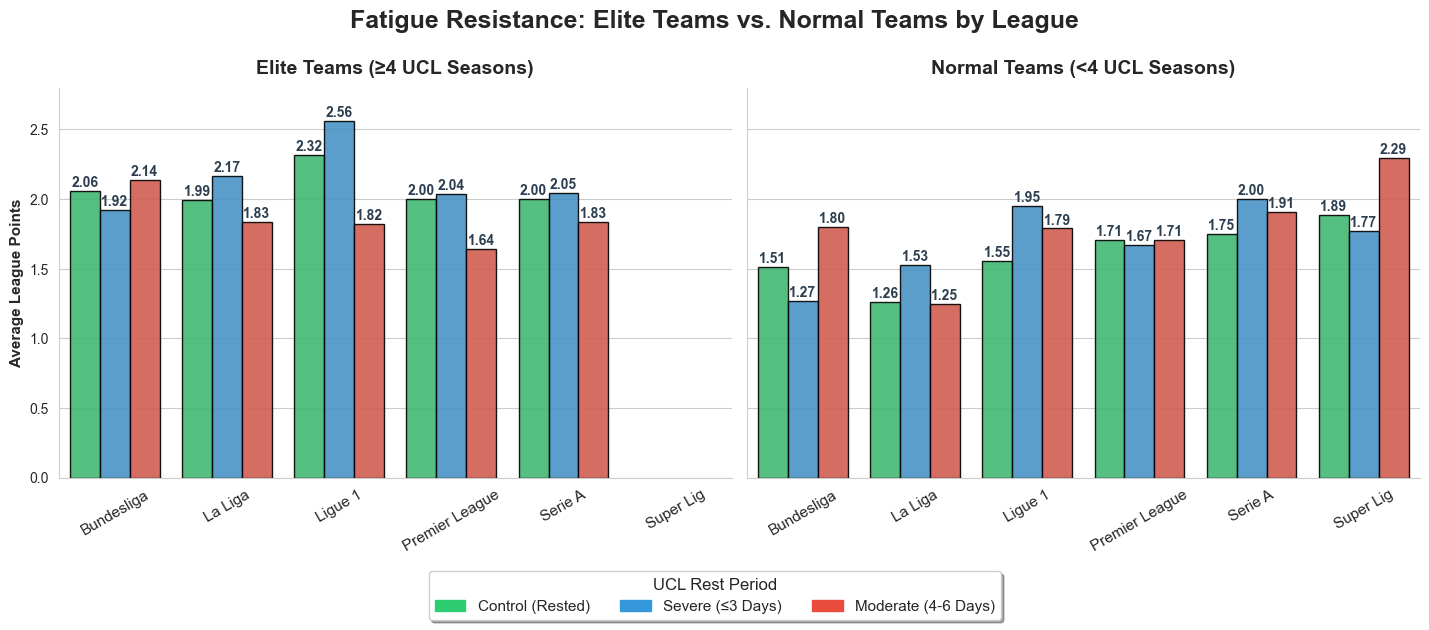

In [160]:
# 1. Identify UCL matches and active seasons
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()

# Count how many seasons each team played in the UCL within the dataset
ucl_counts = active_ucl_seasons.groupby('target_team')['season'].count().reset_index()
ucl_counts.columns = ['target_team', 'ucl_appearances']

# 2. Define Elite Teams (≥ 4 appearances out of 6 seasons) vs Normal Teams
ucl_counts['Team Tier'] = np.where(
    ucl_counts['ucl_appearances'] >= 4, 
    'Elite Teams (≥4 UCL Seasons)', 
    'Normal Teams (<4 UCL Seasons)'
)

# 3. Merge this tier info with the valid league matches
valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')
valid_league_matches = pd.merge(valid_league_matches, ucl_counts[['target_team', 'Team Tier']], on='target_team', how='left')

# Categorize rest period clearly
valid_league_matches['Rest Period'] = valid_league_matches['ucl_impact_category'].map({
    'no_effect': 'Control (Rested)',
    'severe': 'Severe (≤3 Days)',
    'moderate': 'Moderate (4-6 Days)'
})

# Clean up competition names for the plot
valid_league_matches['competition'] = valid_league_matches['competition'].str.replace('_', ' ')

# 4. Aggregate the data
tier_stats = valid_league_matches.groupby(['competition', 'Team Tier', 'Rest Period']).agg(
    mean_points=('points', 'mean')
).reset_index()

category_order = ['Control (Rested)', 'Severe (≤3 Days)', 'Moderate (4-6 Days)']

# 5. Visualization Setup: FacetGrid for Side-by-Side comparison
g = sns.catplot(
    data=tier_stats,
    x='competition',
    y='mean_points',
    hue='Rest Period',
    hue_order=category_order,
    col='Team Tier',
    kind='bar',
    palette=['#2ecc71', '#3498db', '#e74c3c'], # Green, Blue, Red
    height=6,
    aspect=1.2,
    alpha=0.9,
    edgecolor='black',
    legend=False # Kendi özel lejantımızı ekleyeceğiz
)

# 6. Formatting and adding value labels
for ax in g.axes.flat:
    ax.set_ylim(0, 2.8)
    ax.set_ylabel("Average League Points", fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    ax.set_title(ax.get_title().split('=')[1].strip(), fontsize=14, fontweight='bold', pad=10)
    
    # Add values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 0.03, 
                f'{height:.2f}', 
                ha='center', fontsize=10, fontweight='bold', color='#2c3e50'
            )


# 7. Add robust custom legend at the BOTTOM (Bulletproof method)
# Kendi renk paletimizi ve isimlerimizi kullanarak manuel kutucuklar (patches) oluşturuyoruz
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Control (Rested)'),
    mpatches.Patch(color='#3498db', label='Severe (≤3 Days)'),
    mpatches.Patch(color='#e74c3c', label='Moderate (4-6 Days)')
]
g.fig.legend(
    handles=legend_patches, 
    title='UCL Rest Period', 
    title_fontsize=12,
    loc='lower center', 
    ncol=3, # 3 öğeyi yan yana diz
    frameon=True, 
    shadow=True, 
    fontsize=11, 
    bbox_to_anchor=(0.5, -0.05) 
)
# Adjust the subplots to make room for Title (top) and Legend (bottom)
g.fig.subplots_adjust(top=0.85, bottom=0.20) 
g.fig.suptitle("Fatigue Resistance: Elite Teams vs. Normal Teams by League", fontsize=18, fontweight='bold')
plt.show()



Question 8: Does new UCL format increase fatigue?

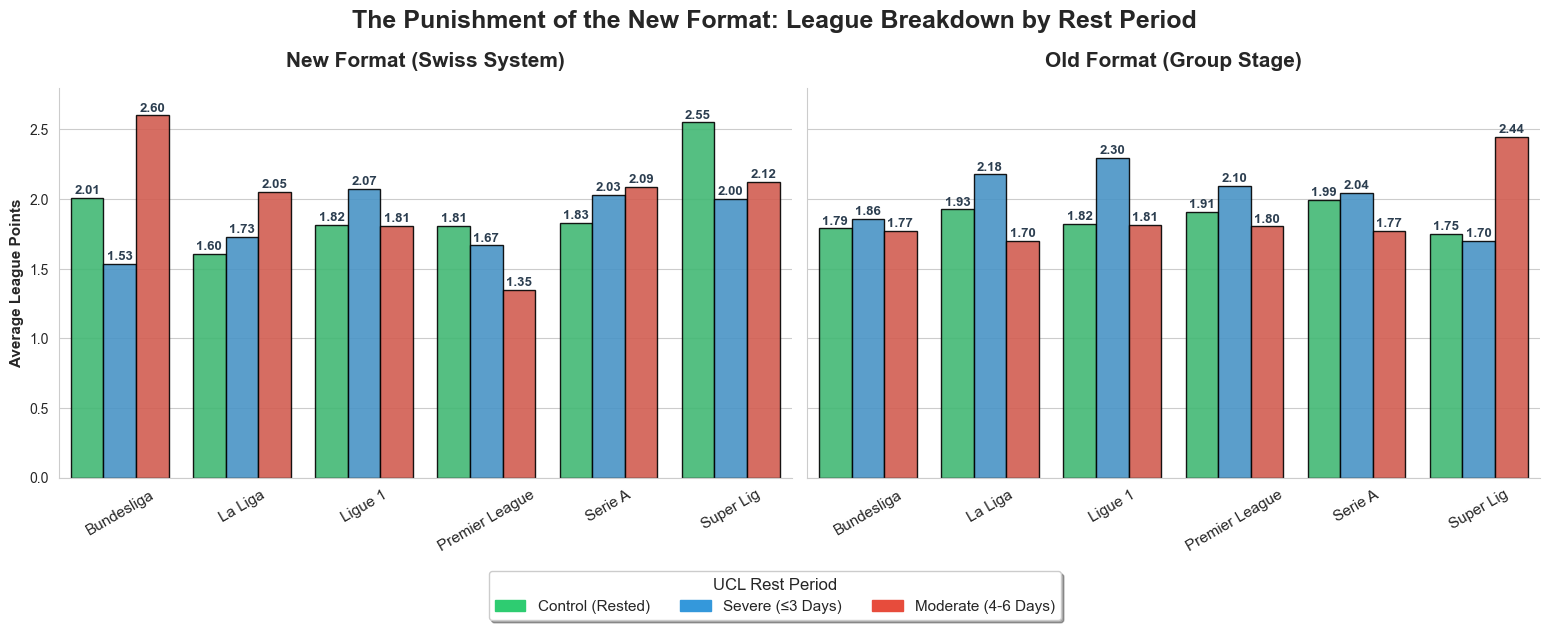

In [161]:
# 1. Filter valid league matches for active UCL seasons
active_ucl_seasons = team_centric_matches[
    team_centric_matches['competition'] == 'Champions_League'
][['target_team', 'season']].drop_duplicates()

valid_league_matches = pd.merge(league_matches, active_ucl_seasons, on=['target_team', 'season'], how='inner')

# 2. Determine UCL Format based on season
new_format_seasons = ['2024-2025', '2025-2026']
valid_league_matches['UCL Format'] = valid_league_matches['season'].apply(
    lambda x: 'New Format (Swiss System)' if x in new_format_seasons else 'Old Format (Group Stage)'
)

# 3. Categorize rest period
valid_league_matches['Rest Period'] = valid_league_matches['ucl_impact_category'].map({
    'no_effect': 'Control (Rested)',
    'severe': 'Severe (≤3 Days)',
    'moderate': 'Moderate (4-6 Days)'
})
category_order = ['Control (Rested)', 'Severe (≤3 Days)', 'Moderate (4-6 Days)']
valid_league_matches['competition'] = valid_league_matches['competition'].str.replace('_', ' ')

# 4. Aggregation for league level
league_format = valid_league_matches.groupby(['competition', 'UCL Format', 'Rest Period']).agg(
    mean_points=('points', 'mean')
).reset_index()

# 5. Visualization Setup: FacetGrid for Side-by-Side Comparison
g = sns.catplot(
    data=league_format,
    x='competition',
    y='mean_points',
    hue='Rest Period',
    hue_order=category_order,
    col='UCL Format', # Yan yana iki grafik ayıracı
    kind='bar',
    palette=['#2ecc71', '#3498db', '#e74c3c'], # Green, Blue, Red
    height=6,
    aspect=1.3,
    alpha=0.9,
    edgecolor='black',
    legend=False # Custom legend ekleyeceğiz
)

# 6. Formatting
for ax in g.axes.flat:
    ax.set_ylim(0, 2.8)
    ax.set_ylabel("Average League Points", fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    
    # Başlıklardaki "UCL Format =" yazısını temizleyelim
    ax.set_title(ax.get_title().split('=')[1].strip(), fontsize=15, fontweight='bold', pad=15)
    
    # Add values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 0.03, 
                f'{height:.2f}', 
                ha='center', fontsize=9.5, fontweight='bold', color='#2c3e50'
            )

# 7. Custom Bottom Legend
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Control (Rested)'),
    mpatches.Patch(color='#3498db', label='Severe (≤3 Days)'),
    mpatches.Patch(color='#e74c3c', label='Moderate (4-6 Days)')
]

g.fig.legend(
    handles=legend_patches, 
    title='UCL Rest Period', 
    title_fontsize=12,
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    shadow=True, 
    fontsize=11, 
    bbox_to_anchor=(0.5, -0.05)
)

g.fig.subplots_adjust(top=0.85, bottom=0.20)
g.fig.suptitle("The Punishment of the New Format: League Breakdown by Rest Period", fontsize=18, fontweight='bold')

plt.show()
